In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# ── Plot defaults ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = sns.color_palette('Set2')

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [4]:
# ── Missing values ─────────────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])

# Drop columns with no analytical value
drop_cols = ['Customer Email', 'Customer Password', 'Product Description',
             'Product Image', 'Order Zipcode']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ── Date parsing ───────────────────────────────────────────────────────────────
df['order_date']    = pd.to_datetime(df['order date (DateOrders)'],    format='%m/%d/%Y %H:%M', errors='coerce')
df['shipping_date'] = pd.to_datetime(df['shipping date (DateOrders)'], format='%m/%d/%Y %H:%M', errors='coerce')

df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_dow']     = df['order_date'].dt.day_name()

# ── Derived KPIs ───────────────────────────────────────────────────────────────
df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['is_late']        = (df['shipping_delay'] > 0).astype(int)

print('\nFeature engineering done.')
print(f"Date range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")

Columns with missing values:
Customer Lname      8
Customer Zipcode    3
dtype: int64

Feature engineering done.
Date range: 2015-01-01 → 2018-01-31


In [6]:
# ── Basic stats ────────────────────────────────────────────────────────────────
print('=== Dataset Overview ===')
print(f'Total Orders        : {df["Order Id"].nunique():,}')
print(f'Total Customers     : {df["Customer Id"].nunique():,}')
print(f'Total Products      : {df["Product Name"].nunique():,}')
print(f'Markets             : {df["Market"].nunique()}')
print(f'Order Countries     : {df["Order Country"].nunique()}')
print(f'Total Revenue       : ${df["Sales"].sum():,.0f}')
print(f'Total Profit        : ${df["Order Profit Per Order"].sum():,.0f}')
print(f'Avg Profit / Order  : ${df["Order Profit Per Order"].mean():.2f}')
print(f'Late Delivery Rate  : {df["is_late"].mean()*100:.1f}%')

=== Dataset Overview ===
Total Orders        : 65,752
Total Customers     : 20,652
Total Products      : 118
Markets             : 5
Order Countries     : 164
Total Revenue       : $36,784,735
Total Profit        : $3,966,903
Avg Profit / Order  : $21.97
Late Delivery Rate  : 57.3%


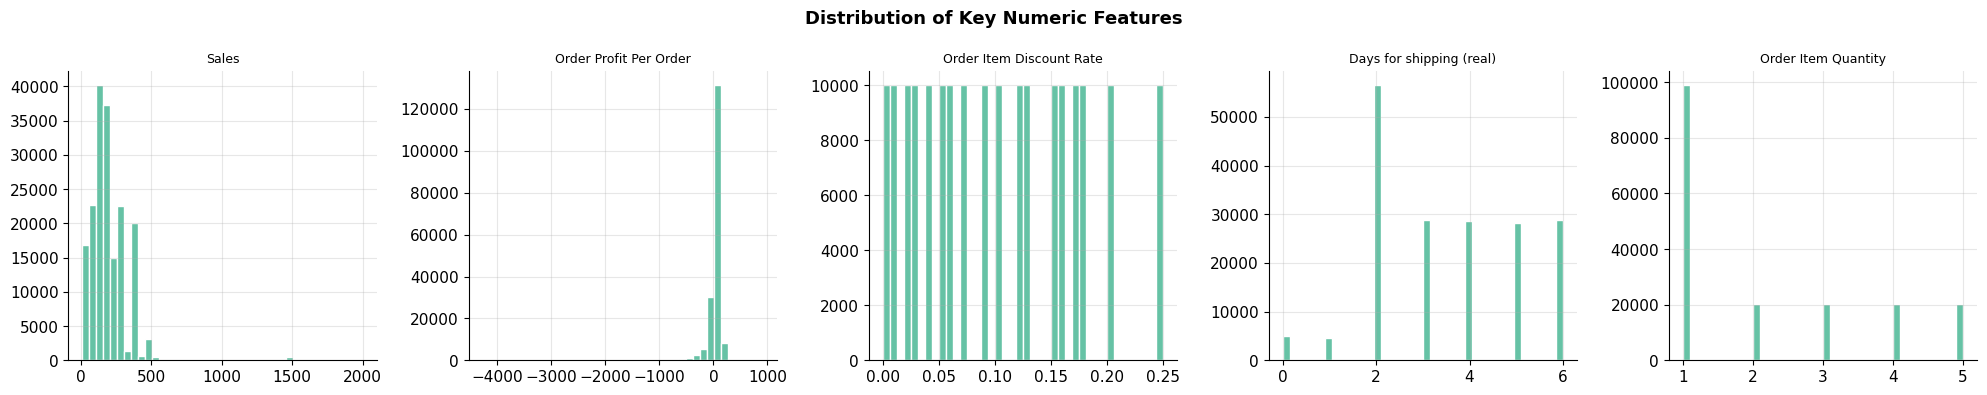

In [8]:
# ── Distribution of key numeric columns ──────────────────────────────────────
num_cols = ['Sales', 'Order Profit Per Order', 'Order Item Discount Rate',
            'Days for shipping (real)', 'Order Item Quantity']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=40, color=PALETTE[0], edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Distribution of Key Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

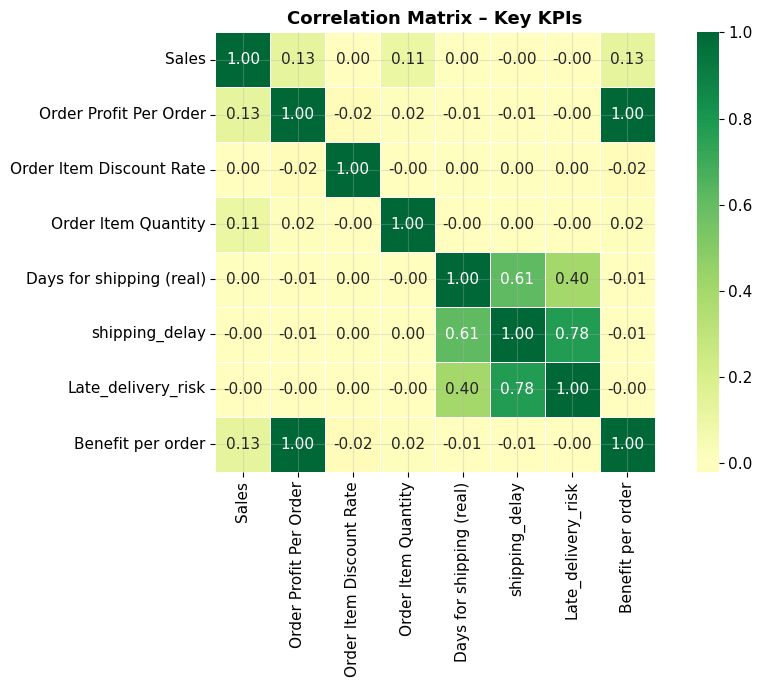

In [9]:
# ── Correlation heat-map ───────────────────────────────────────────────────────
corr_cols = ['Sales', 'Order Profit Per Order', 'Order Item Discount Rate',
             'Order Item Quantity', 'Days for shipping (real)',
             'shipping_delay', 'Late_delivery_risk', 'Benefit per order']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix – Key KPIs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── Create in-memory SQLite DB ─────────────────────────────────────────────────
conn = sqlite3.connect(':memory:')
df.to_sql('supply_chain', conn, index=False, if_exists='replace')
print('Table loaded into SQLite.')

def sql(query):
    """Helper: run SQL and return a DataFrame."""
    return pd.read_sql_query(query, conn)

Table loaded into SQLite.


In [13]:
# SQL Q1 – Top 10 most profitable product categories
q1 = sql("""
    SELECT  "Category Name",
            ROUND(SUM("Order Profit Per Order"), 2)  AS total_profit,
            ROUND(AVG("Order Profit Per Order"), 2)  AS avg_profit,
            COUNT(*)                                  AS order_count
    FROM    supply_chain
    GROUP BY "Category Name"
    ORDER BY total_profit DESC
    LIMIT 10
""")
print('Top 10 Product Categories by Profit')
q1

Top 10 Product Categories by Profit


,Category Name,total_profit,avg_profit,order_count
0,Fishing,756220.77,43.65,17325
1,Cleats,494636.92,20.15,24551
2,Camping & Hiking,427455.57,31.14,13729
3,Cardio Equipment,383011.10,30.67,12487
4,Women's Apparel,350421.03,16.66,21035
5,Water Sports,325146.96,20.92,15540
6,Indoor/Outdoor Games,318451.43,16.50,19298
7,Men's Footwear,311902.82,14.02,22246
8,Shop By Sport,129813.96,11.82,10984
9,Computers,69656.81,157.59,442


In [14]:
# SQL Q2 – Late delivery rate per shipping mode
q2 = sql("""
    SELECT  "Shipping Mode",
            COUNT(*)                                          AS total_orders,
            SUM(is_late)                                      AS late_orders,
            ROUND(100.0 * SUM(is_late) / COUNT(*), 1)        AS late_pct
    FROM    supply_chain
    GROUP BY "Shipping Mode"
    ORDER BY late_pct DESC
""")
print('Late Delivery Rate by Shipping Mode')
q2

Late Delivery Rate by Shipping Mode


,Shipping Mode,total_orders,late_orders,late_pct
0,First Class,27814,27814,100.0
1,Second Class,35216,28078,79.7
2,Same Day,9737,4657,47.8
3,Standard Class,107752,42851,39.8


In [15]:
# SQL Q3 – Revenue & profit by market
q3 = sql("""
    SELECT  Market,
            ROUND(SUM(Sales), 0)                AS total_revenue,
            ROUND(SUM("Order Profit Per Order"), 0) AS total_profit,
            ROUND(100.0 * SUM("Order Profit Per Order") / SUM(Sales), 1) AS profit_margin_pct
    FROM    supply_chain
    GROUP BY Market
    ORDER BY total_revenue DESC
""")
print('Revenue & Profit by Market')
q3

Revenue & Profit by Market


,Market,total_revenue,total_profit,profit_margin_pct
0,Europe,10872397.0,1169443.0,10.8
1,LATAM,10277613.0,1123322.0,10.9
2,Pacific Asia,8273744.0,857753.0,10.4
3,USCA,5066529.0,564314.0,11.1
4,Africa,2294453.0,252071.0,11.0


In [16]:
# SQL Q4 – Order status breakdown
q4 = sql("""
    SELECT  "Order Status",
            COUNT(*)                                    AS count,
            ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM supply_chain), 1) AS pct
    FROM    supply_chain
    GROUP BY "Order Status"
    ORDER BY count DESC
""")
print('Order Status Distribution')
q4

Order Status Distribution


,Order Status,count,pct
0,COMPLETE,59491,33.0
1,PENDING_PAYMENT,39832,22.1
2,PROCESSING,21902,12.1
3,PENDING,20227,11.2
4,CLOSED,19616,10.9
5,ON_HOLD,9804,5.4
6,SUSPECTED_FRAUD,4062,2.3
7,CANCELED,3692,2.0
8,PAYMENT_REVIEW,1893,1.0


In [17]:
# SQL Q5 – Top 10 customers by revenue
q5 = sql("""
    SELECT  "Customer Fname" || ' ' || "Customer Lname" AS customer_name,
            "Customer Segment",
            "Customer Country",
            COUNT(DISTINCT "Order Id")                  AS orders,
            ROUND(SUM(Sales), 0)                        AS total_spend
    FROM    supply_chain
    GROUP BY "Customer Id"
    ORDER BY total_spend DESC
    LIMIT 10
""")
print('Top 10 Customers by Revenue')
q5

Top 10 Customers by Revenue


,customer_name,Customer Segment,Customer Country,orders,total_spend
0,Mary Smith,Corporate,EE. UU.,13,10524.0
1,Mary Patterson,Consumer,EE. UU.,11,9299.0
2,Mary Duncan,Corporate,Puerto Rico,11,9296.0
3,Betty Phillips,Consumer,Puerto Rico,11,9224.0
4,Betty Spears,Consumer,EE. UU.,11,9131.0
5,Ashley Smith,Consumer,EE. UU.,14,9019.0
6,Evelyn Thompson,Home Office,Puerto Rico,12,9019.0
7,Mary Butler,Consumer,Puerto Rico,13,8919.0
8,Jerry Smith,Home Office,Puerto Rico,15,8905.0
9,Mary Mata,Consumer,Puerto Rico,12,8762.0


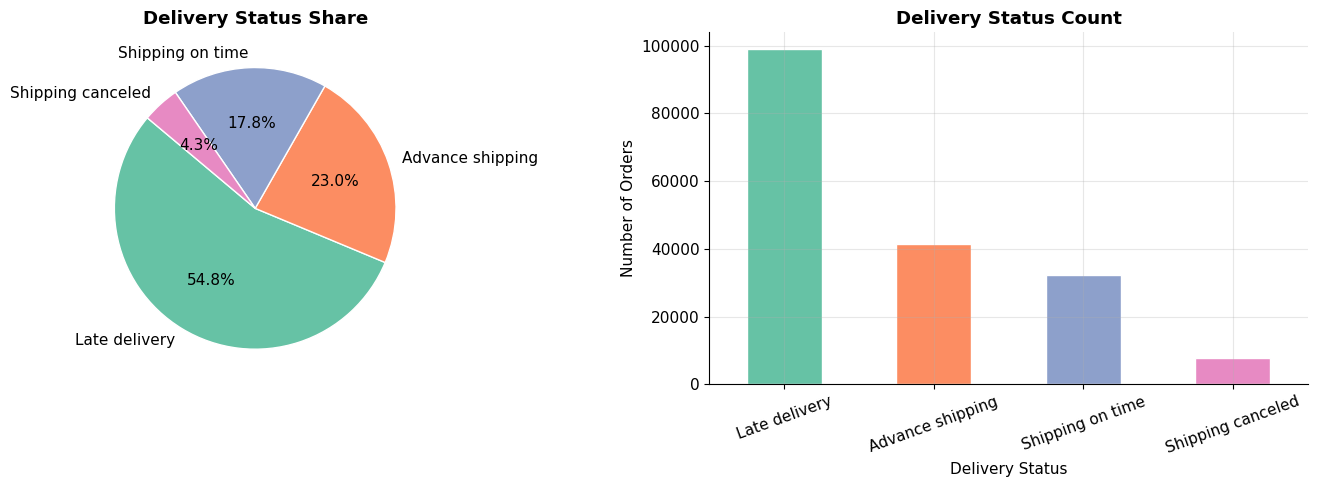

In [18]:
# ── Delivery status distribution ──────────────────────────────────────────────
delivery_counts = df['Delivery Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie
axes[0].pie(delivery_counts, labels=delivery_counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=140, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Delivery Status Share', fontweight='bold')

# Bar
delivery_counts.plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor='white', rot=20)
axes[1].set_title('Delivery Status Count', fontweight='bold')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

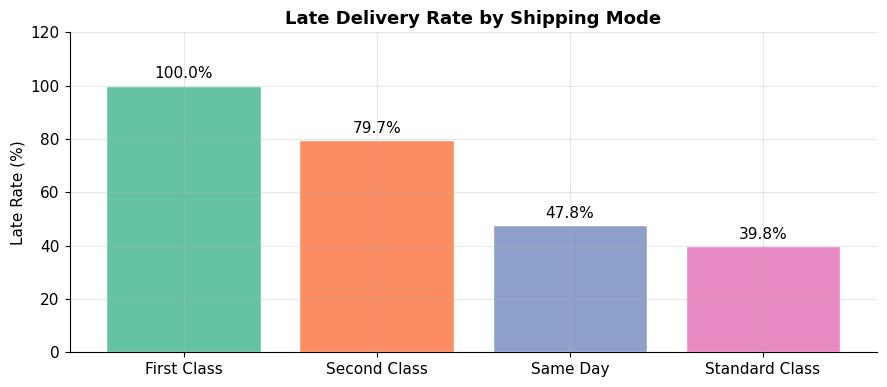

In [19]:
# ── Late delivery rate by shipping mode ──────────────────────────────────────
late_by_mode = df.groupby('Shipping Mode')['is_late'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(late_by_mode.index, late_by_mode.values, color=PALETTE, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Late Delivery Rate by Shipping Mode', fontsize=13, fontweight='bold')
ax.set_ylabel('Late Rate (%)')
ax.set_ylim(0, late_by_mode.max() * 1.2)
plt.tight_layout()
plt.show()

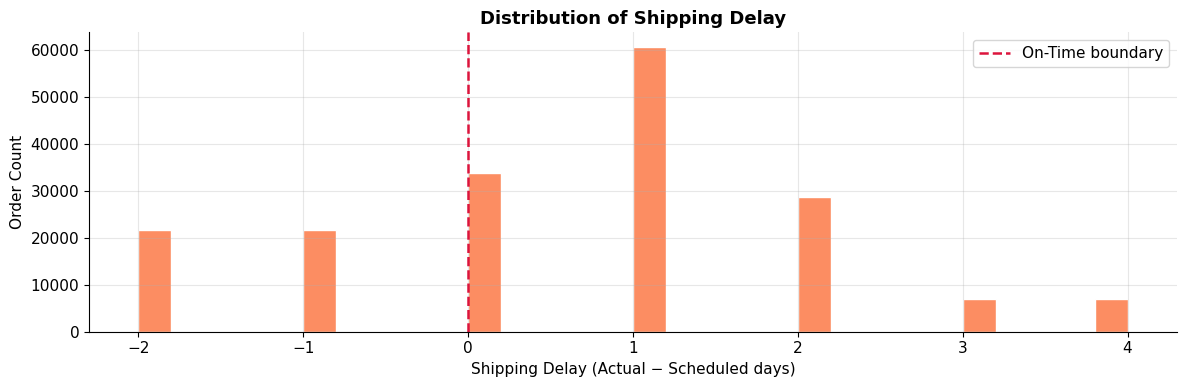

In [20]:
# ── Shipping delay distribution ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df['shipping_delay'].clip(-5, 10), bins=30, color=PALETTE[1], edgecolor='white')
ax.axvline(0, color='crimson', linestyle='--', linewidth=1.8, label='On-Time boundary')
ax.set_xlabel('Shipping Delay (Actual − Scheduled days)')
ax.set_ylabel('Order Count')
ax.set_title('Distribution of Shipping Delay', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

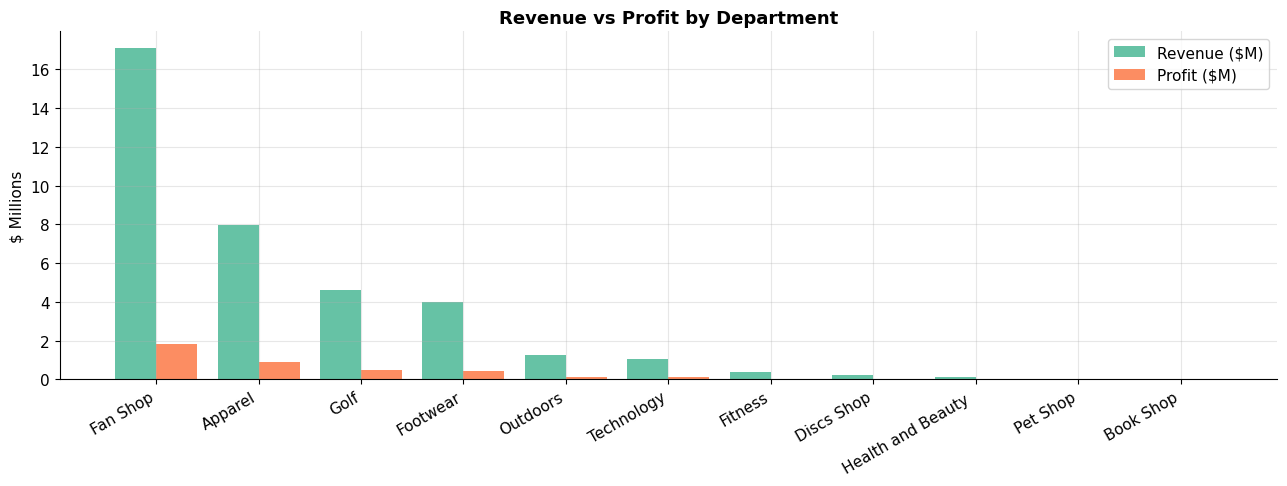

In [22]:
# ── Revenue & profit by department ───────────────────────────────────────────
dept = (df.groupby('Department Name')
          .agg(Revenue=('Sales', 'sum'), Profit=('Order Profit Per Order', 'sum'))
          .sort_values('Revenue', ascending=False))

x = range(len(dept))
fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar([i - 0.2 for i in x], dept['Revenue'] / 1e6, width=0.4, label='Revenue ($M)', color=PALETTE[0])
bars2 = ax.bar([i + 0.2 for i in x], dept['Profit']  / 1e6, width=0.4, label='Profit ($M)',  color=PALETTE[1])
ax.set_xticks(list(x))
ax.set_xticklabels(dept.index, rotation=30, ha='right')
ax.set_ylabel('$ Millions')
ax.set_title('Revenue vs Profit by Department', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

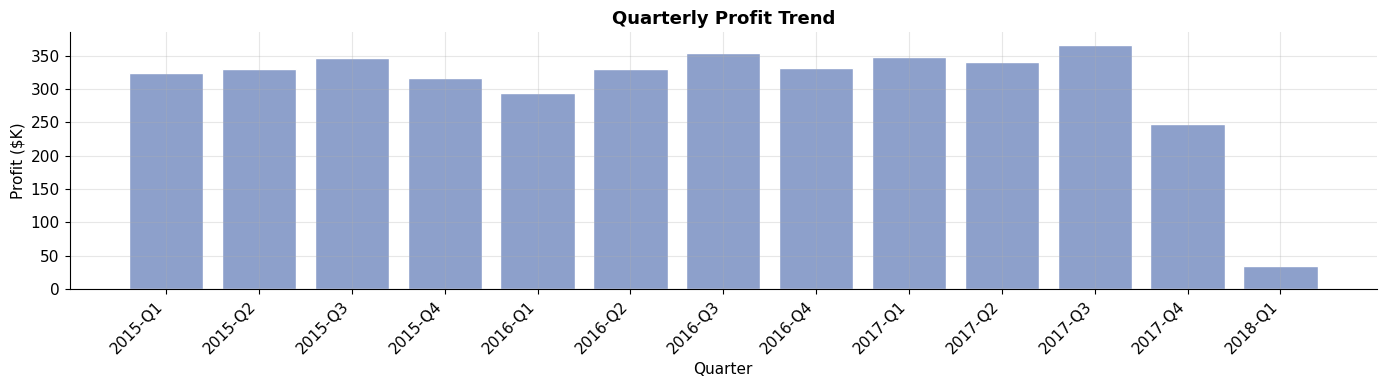

In [23]:
# ── Quarterly profit trend ────────────────────────────────────────────────────
qtr = (df.groupby(['order_year', 'order_quarter'])['Order Profit Per Order']
         .sum()
         .reset_index())
qtr['label'] = qtr['order_year'].astype(str) + '-Q' + qtr['order_quarter'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(qtr['label'], qtr['Order Profit Per Order'] / 1e3, color=PALETTE[2], edgecolor='white')
ax.set_xlabel('Quarter')
ax.set_ylabel('Profit ($K)')
ax.set_title('Quarterly Profit Trend', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

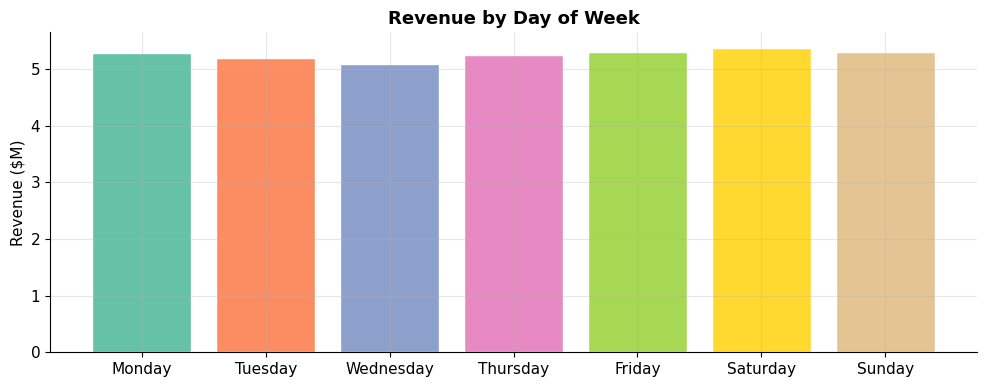

In [24]:
# ── Sales by day of week ──────────────────────────────────────────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df.groupby('order_dow')['Sales'].sum().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dow_sales.index, dow_sales.values / 1e6, color=PALETTE, edgecolor='white')
ax.set_ylabel('Revenue ($M)')
ax.set_title('Revenue by Day of Week', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

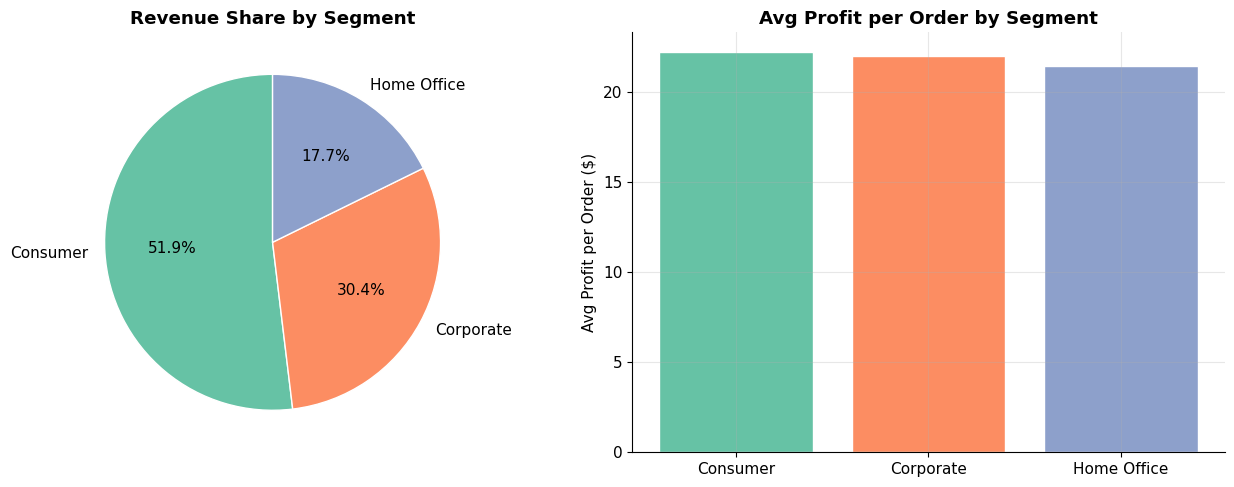

In [25]:
# ── Revenue split by customer segment ────────────────────────────────────────
seg_rev = df.groupby('Customer Segment')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(seg_rev, labels=seg_rev.index, autopct='%1.1f%%',
            colors=PALETTE[:len(seg_rev)], startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Revenue Share by Segment', fontweight='bold')

seg_profit = df.groupby('Customer Segment')['Order Profit Per Order'].mean()
axes[1].bar(seg_profit.index, seg_profit.values, color=PALETTE[:len(seg_profit)], edgecolor='white')
axes[1].set_ylabel('Avg Profit per Order ($)')
axes[1].set_title('Avg Profit per Order by Segment', fontweight='bold')

plt.tight_layout()
plt.show()

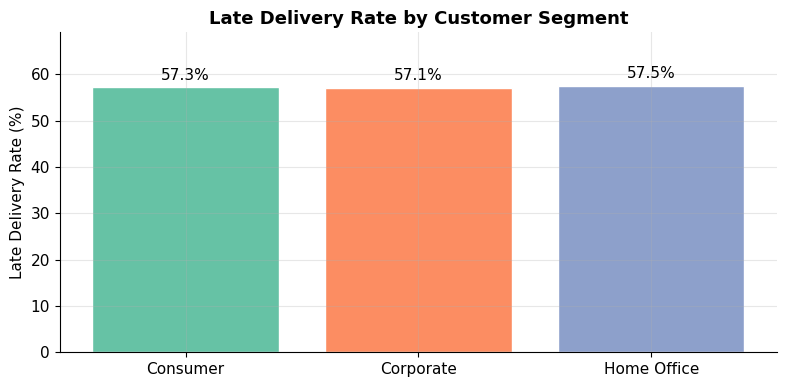

In [26]:
# ── Late delivery risk by segment ────────────────────────────────────────────
seg_late = df.groupby('Customer Segment')['is_late'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(seg_late.index, seg_late.values, color=PALETTE[:3], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by Customer Segment', fontsize=13, fontweight='bold')
ax.set_ylim(0, seg_late.max() * 1.2)
plt.tight_layout()
plt.show()

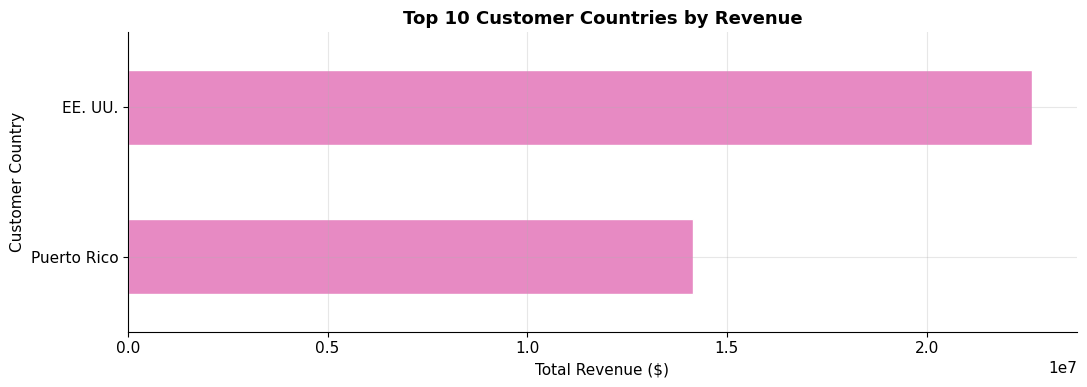

In [27]:
# ── Top 10 customer countries by revenue ─────────────────────────────────────
top_countries = df.groupby('Customer Country')['Sales'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(11, 4))
top_countries.sort_values().plot(kind='barh', ax=ax, color=PALETTE[3], edgecolor='white')
ax.set_xlabel('Total Revenue ($)')
ax.set_title('Top 10 Customer Countries by Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

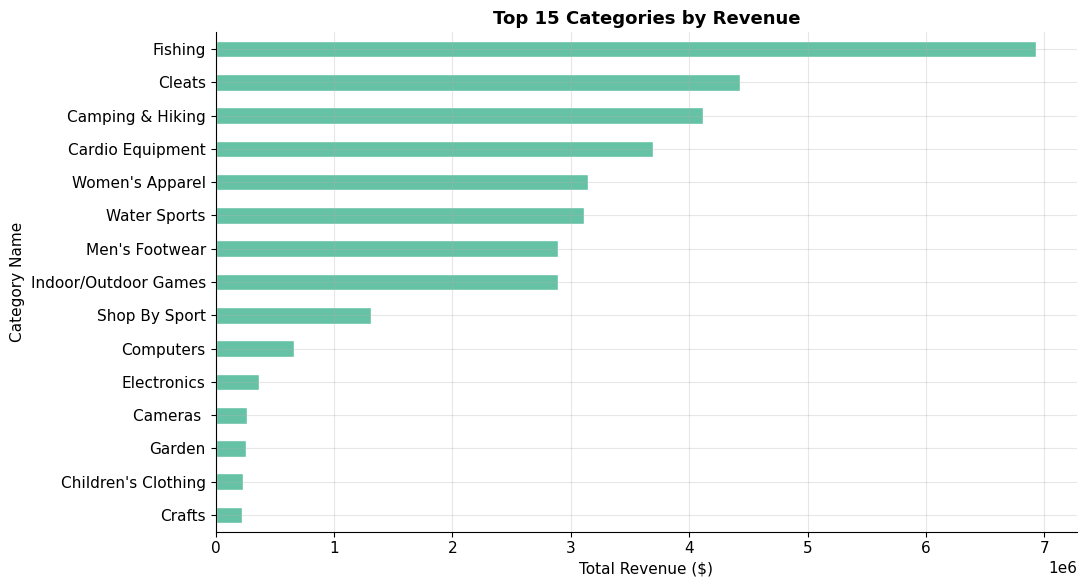

In [28]:
# ── Top 15 product categories by revenue ─────────────────────────────────────
cat_rev = df.groupby('Category Name')['Sales'].sum().nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
cat_rev.plot(kind='barh', ax=ax, color=PALETTE[0], edgecolor='white')
ax.set_xlabel('Total Revenue ($)')
ax.set_title('Top 15 Categories by Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

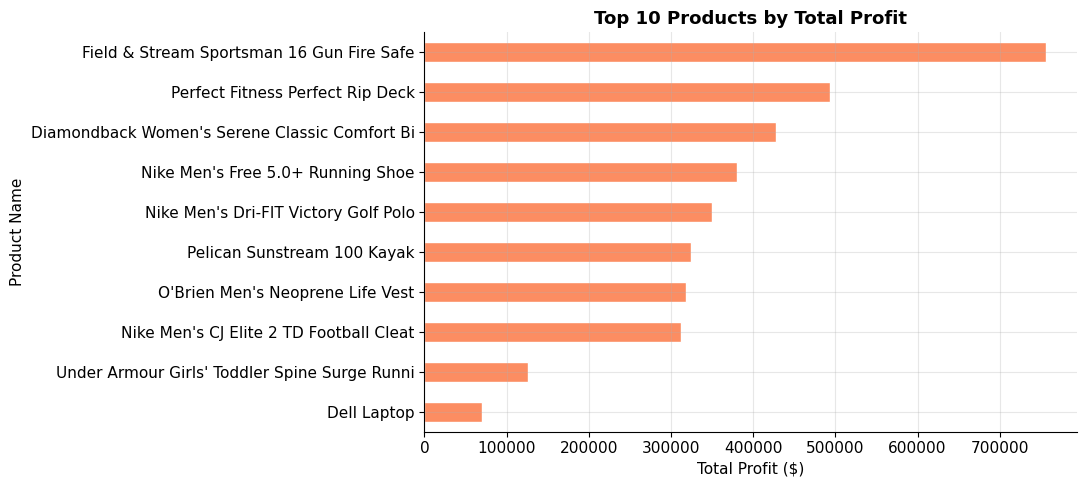

In [29]:
# ── Top 10 products by profit ─────────────────────────────────────────────────
prod_profit = df.groupby('Product Name')['Order Profit Per Order'].sum().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(11, 5))
prod_profit.plot(kind='barh', ax=ax, color=PALETTE[1], edgecolor='white')
ax.set_xlabel('Total Profit ($)')
ax.set_title('Top 10 Products by Total Profit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

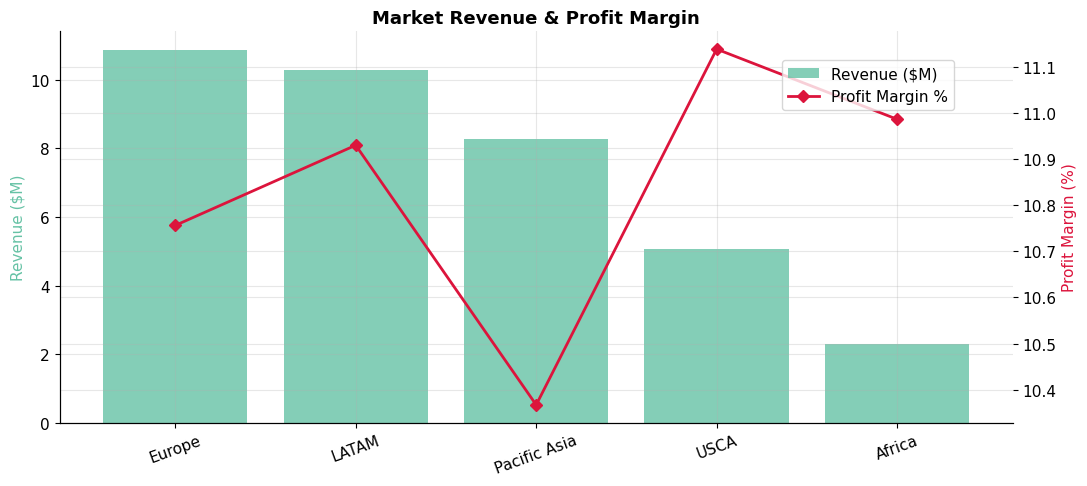

In [30]:
# ── Market revenue & profit margin ───────────────────────────────────────────
market_kpi = (df.groupby('Market')
               .agg(Revenue=('Sales', 'sum'),
                    Profit=('Order Profit Per Order', 'sum'))
               .assign(Margin=lambda x: x['Profit'] / x['Revenue'] * 100)
               .sort_values('Revenue', ascending=False))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = range(len(market_kpi))
ax1.bar(x, market_kpi['Revenue'] / 1e6, color=PALETTE[0], alpha=0.8, label='Revenue ($M)')
ax2.plot(list(x), market_kpi['Margin'], color='crimson', marker='D', linewidth=2, label='Profit Margin %')

ax1.set_xticks(list(x))
ax1.set_xticklabels(market_kpi.index, rotation=20)
ax1.set_ylabel('Revenue ($M)', color=PALETTE[0])
ax2.set_ylabel('Profit Margin (%)', color='crimson')
ax1.set_title('Market Revenue & Profit Margin', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

                Orders  Avg_Real_Days  Avg_Sched_Days      Revenue
Shipping Mode                                                     
Standard Class  107752           4.00             4.0  22022391.88
Second Class     35216           3.99             2.0   7145444.82
First Class      27814           2.00             1.0   5674369.76
Same Day          9737           0.48             0.0   1942528.56


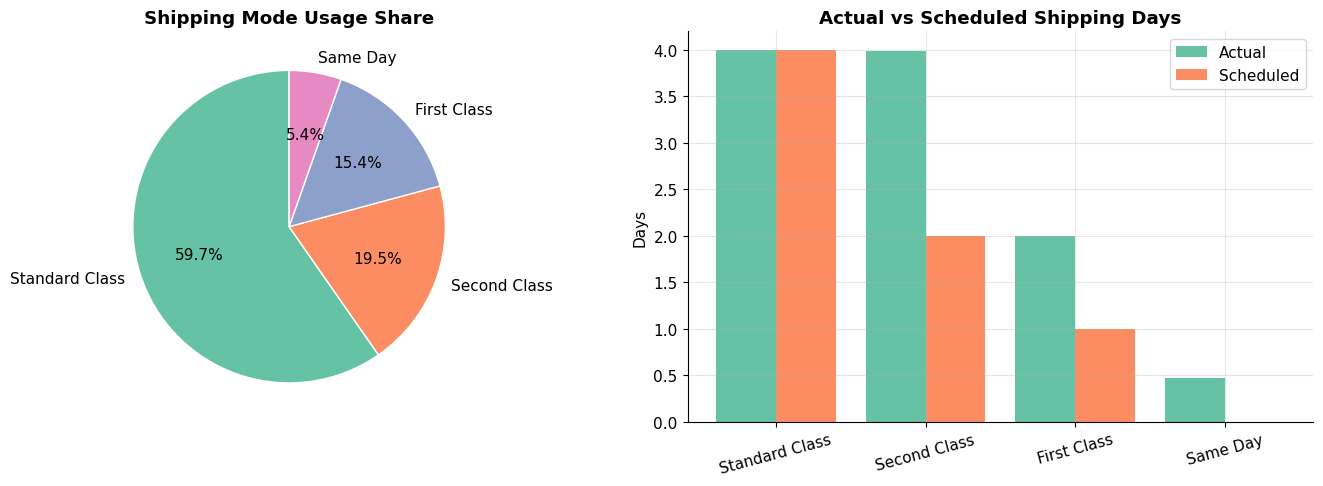

In [31]:
# ── Shipping mode usage and avg days ─────────────────────────────────────────
ship_mode = (df.groupby('Shipping Mode')
               .agg(Orders=('Order Id', 'count'),
                    Avg_Real_Days=('Days for shipping (real)', 'mean'),
                    Avg_Sched_Days=('Days for shipment (scheduled)', 'mean'),
                    Revenue=('Sales', 'sum'))
               .sort_values('Orders', ascending=False))
print(ship_mode.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Usage pie
axes[0].pie(ship_mode['Orders'], labels=ship_mode.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Shipping Mode Usage Share', fontweight='bold')

# Days comparison
x = range(len(ship_mode))
axes[1].bar([i - 0.2 for i in x], ship_mode['Avg_Real_Days'],  width=0.4, label='Actual', color=PALETTE[0])
axes[1].bar([i + 0.2 for i in x], ship_mode['Avg_Sched_Days'], width=0.4, label='Scheduled', color=PALETTE[1])
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(ship_mode.index, rotation=15)
axes[1].set_ylabel('Days')
axes[1].set_title('Actual vs Scheduled Shipping Days', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

Total suspected fraud orders : 4,062
% of total orders            : 2.25%
Revenue at risk              : $825,935


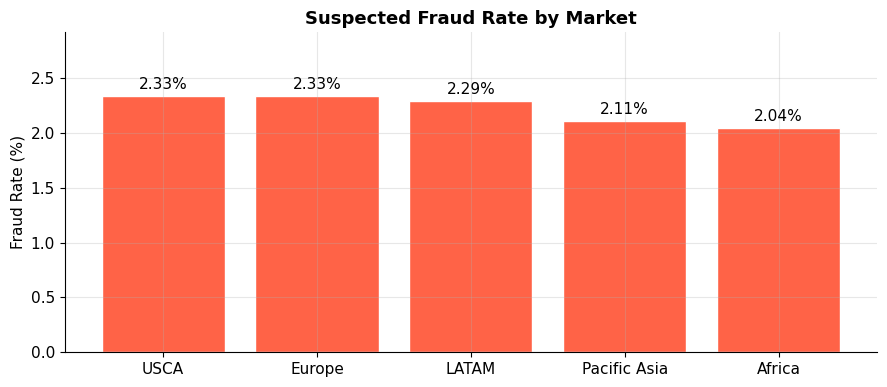

In [32]:
# ── Suspected fraud orders ────────────────────────────────────────────────────
fraud = df[df['Order Status'] == 'SUSPECTED_FRAUD']
print(f'Total suspected fraud orders : {len(fraud):,}')
print(f'% of total orders            : {len(fraud)/len(df)*100:.2f}%')
print(f'Revenue at risk              : ${fraud["Sales"].sum():,.0f}')

# Fraud by market
fraud_mkt = fraud['Market'].value_counts()
total_mkt  = df['Market'].value_counts()
fraud_rate = (fraud_mkt / total_mkt * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(fraud_rate.index, fraud_rate.values, color='tomato', edgecolor='white')
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Suspected Fraud Rate by Market', fontsize=13, fontweight='bold')
ax.set_ylim(0, fraud_rate.max() * 1.25)
plt.tight_layout()
plt.show()

In [33]:
# ── Cancelled orders analysis ─────────────────────────────────────────────────
cancelled = df[df['Order Status'] == 'CANCELED']
print(f'Cancelled orders        : {len(cancelled):,}  ({len(cancelled)/len(df)*100:.1f}%)')
print(f'Revenue lost            : ${cancelled["Sales"].sum():,.0f}')
print('\nCancellations by Market:')
print(cancelled['Market'].value_counts())

Cancelled orders        : 3,692  (2.0%)
Revenue lost            : $744,370

Cancellations by Market:
Market
LATAM           1103
Europe           990
Pacific Asia     806
USCA             570
Africa           223
Name: count, dtype: int64


In [35]:
# ── Printed insight summary ───────────────────────────────────────────────────
print('=' * 60)
print('     KEY BUSINESS INSIGHTS FROM SUPPLY CHAIN DATA')
print('=' * 60)

print(f"""
1. SCALE
   • {df['Order Id'].nunique():,} orders | {df['Customer Id'].nunique():,} customers
   • Total Revenue : ${df['Sales'].sum()/1e6:.1f}M
   • Total Profit  : ${df['Order Profit Per Order'].sum()/1e6:.1f}M
   • Overall Margin: {df['Order Profit Per Order'].sum()/df['Sales'].sum()*100:.1f}%

2. DELIVERY RISK
   • {df['is_late'].mean()*100:.1f}% of orders arrive late
   • Standard Class has the highest late delivery rate
   • LATAM & Africa face the highest regional delivery risk

3. REVENUE LEADERS
   • Top market      : {df.groupby('Market')['Sales'].sum().idxmax()}
   • Top department  : {df.groupby('Department Name')['Sales'].sum().idxmax()}
   • Top category    : {df.groupby('Category Name')['Sales'].sum().idxmax()}

4. CUSTOMER SEGMENTS
   • Consumer segment drives the most revenue
   • Corporate segment has the highest average profit per order

5. FRAUD & RISK
   • Suspected fraud: {len(fraud):,} orders ({len(fraud)/len(df)*100:.2f}%)
   • Fraud revenue exposure: ${fraud['Sales'].sum():,.0f}
   • Cancelled orders: {len(cancelled):,} ({len(cancelled)/len(df)*100:.1f}%)

6. DISCOUNTS
   • Higher discount rates correlate with lower profit ratios
   • Average discount rate: {df['Order Item Discount Rate'].mean()*100:.1f}%
""")
print('=' * 60)

     KEY BUSINESS INSIGHTS FROM SUPPLY CHAIN DATA

1. SCALE
   • 65,752 orders | 20,652 customers
   • Total Revenue : $36.8M
   • Total Profit  : $4.0M
   • Overall Margin: 10.8%

2. DELIVERY RISK
   • 57.3% of orders arrive late
   • Standard Class has the highest late delivery rate
   • LATAM & Africa face the highest regional delivery risk

3. REVENUE LEADERS
   • Top market      : Europe
   • Top department  : Fan Shop
   • Top category    : Fishing

4. CUSTOMER SEGMENTS
   • Consumer segment drives the most revenue
   • Corporate segment has the highest average profit per order

5. FRAUD & RISK
   • Suspected fraud: 4,062 orders (2.25%)
   • Fraud revenue exposure: $825,935
   • Cancelled orders: 3,692 (2.0%)

6. DISCOUNTS
   • Higher discount rates correlate with lower profit ratios
   • Average discount rate: 10.2%

